# **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# **Load training dataset**

In [2]:
train_df=pd.read_csv("/content/finance_project_train_data.csv")

In [3]:
train_df.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# **Basic Inspection of training data**

In [4]:
train_df.shape

(1976, 10)

In [5]:
train_df.columns

Index(['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR',
       ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR'],
      dtype='object')

In [6]:
train_df.isnull().sum()
#here we can see there are no null values or missing values
#So we do NOT need additional missing-value handling after this.

,0
Date,0
ZC025YR,0
ZC050YR,0
ZC075YR,0
ZC100YR,0
ZC200YR,0
ZC500YR,0
ZC1000YR,0
ZC2000YR,0
ZC3000YR,0


# **Data Engineering And Preprocessing**

# **Convert date column**

In [7]:
# Replace 'Date' with actual date column name if different
train_df['Date'] = pd.to_datetime(train_df['Date'])

# sort by date
train_df = train_df.sort_values('Date')

# set date as index Because financial data is time-series data.
train_df.set_index('Date', inplace=True)

In [8]:
train_df.head()

,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# **Remove Duplicates**

In [9]:
train_df = train_df.drop_duplicates()

In [10]:
train_df.head()

,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [11]:
train_df.shape

(1976, 9)

# **Outlier Detection**
When we used '1.5' as multiplier of IQR, it considered 300 to 400 rows as outliers. These aren't errors—they are real historical moments when central banks rapidly shifted rates due to inflation or economic crises. If we delete them, we erase the exact market volatility our CIR model needs to learn.  
So we used '3' as a multiplier of IQR here,and it is giving 0 outliers ,this proves our data has zero corrupted data entry errors, but keeps 100% of the genuine economic history intact for a realistic calibration.

In [12]:
for col in train_df.columns:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]

    print(f"{col} : {len(outliers)} outliers detected")



 ZC025YR : 0 outliers detected
 ZC050YR : 0 outliers detected
 ZC075YR : 0 outliers detected
 ZC100YR : 0 outliers detected
 ZC200YR : 0 outliers detected
 ZC500YR : 0 outliers detected
 ZC1000YR : 0 outliers detected
 ZC2000YR : 0 outliers detected
 ZC3000YR : 0 outliers detected


# **Outlier Normalization**

In [13]:
# Normalize outliers
train_df[col] = np.clip(train_df[col], lower, upper)

# **Check for negative yields**

In [14]:
# this is required because positive interest rates very important for CIR.

print((train_df < 0).sum())

#here no negative values are there in the dataset which is good for CIR model

ZC025YR     0
ZC050YR     0
ZC075YR     0
ZC100YR     0
ZC200YR     0
ZC500YR     0
ZC1000YR    0
ZC2000YR    0
ZC3000YR    0
dtype: int64


# **Final Data Validation**

In [15]:

print(train_df.info())

print(train_df.isnull().sum().sum())

print(np.isinf(train_df.values).sum())



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1976 entries, 2016-05-19 to 2024-04-26
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0    ZC025YR   1976 non-null   float64
 1    ZC050YR   1976 non-null   float64
 2    ZC075YR   1976 non-null   float64
 3    ZC100YR   1976 non-null   float64
 4    ZC200YR   1976 non-null   float64
 5    ZC500YR   1976 non-null   float64
 6    ZC1000YR  1976 non-null   float64
 7    ZC2000YR  1976 non-null   float64
 8    ZC3000YR  1976 non-null   float64
dtypes: float64(9)
memory usage: 154.4 KB
None
0
0


# **Load Test Datasets**

In [16]:
# load only 3M test dataset
# Used as input to CIR model
test_3m = pd.read_csv("/content/finance_project_test_data_3M.csv")


# load full test dataset
# Used only for evaluation/comparison
test_full = pd.read_csv("/content/finance_project_test_data.csv")

# Remove extra spaces from column names
test_full.columns = test_full.columns.str.strip()

In [17]:
test_full.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072


In [18]:
test_3m.head()

,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100
3,2024-05-02,0.048921
4,2024-05-03,0.048633


# **Test Data Engineering and Preprocessing**

In [19]:
# Sort both datasets by date so that observations are in correct time order
test_3m = test_3m.sort_values('Date').reset_index(drop=True)
test_full = test_full.sort_values('Date').reset_index(drop=True)

# Handle missing observations if present using forward and backward filling
test_3m = test_3m.ffill().bfill()
test_full = test_full.ffill().bfill()

# Verify that no missing values remain in the datasets
print("Null verification in test sets (3M / Full):",
      test_3m.isnull().sum().sum(), "/",
      test_full.isnull().sum().sum())

# Clean column name by removing unwanted spaces
test_3m.columns = test_3m.columns.str.strip()

#  Extract the short-rate proxy (3-month yield) for testing (rt Proxy)
test_r = test_3m['ZC025YR'].values

# Display a few sample values
print("First 5 out-of-sample 3M benchmark inputs:", test_r[:5])

Null verification in test sets (3M / Full): 0 / 0
First 5 out-of-sample 3M benchmark inputs: [0.0491444 0.0491565 0.0491005 0.0489207 0.0486329]


# **Training Yield Curve Data Preparation**
This section prepares the training data for CIR calibration.
Here, we are taking all the columns of the training dataset to estimate the values of the parameters because the entire yield curve contains valuable market information about future interest rate expectations, inflation, and risk premiums. Calibrating to all maturities simultaneously forces the CIR model to find parameters that best fit the actual shape and slope of the whole curve today, rather than just guessing based on a single short rate over time.

In [20]:
from scipy.optimize import minimize

# Remove spaces from column names
train_df.columns = train_df.columns.str.strip()

# Define Full Training Yield Curve Columns
maturity_cols = [
    'ZC025YR',   # 3M
    'ZC050YR',   # 6M
    'ZC075YR',   # 9M
    'ZC100YR',   # 1Y
    'ZC200YR',   # 2Y
    'ZC500YR',   # 5y
    'ZC1000YR',  # 10y
    'ZC2000YR',  # 20y
    'ZC3000YR',  # 30y
]

# Extract all historical yields into a 2D matrix
train_rates = train_df[maturity_cols].values
print("Shape of full training matrix:", train_rates.shape)

# Define exact historical maturities in years matching your columns above
# These will be mapped to the columns inside the optimization function
train_maturities = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

# Clean up data: ensure all values are positive for mathematical viability
train_rates[train_rates <= 0] = 1e-4

Shape of full training matrix: (1976, 9)


# **Define CIR Analytical Pricing Functions**
The Cox–Ingersoll–Ross (CIR) model assumes that the short-term interest rate evolves according to a mean-reverting stochastic differential equation. Unlike simpler interest rate models, the CIR process incorporates a square-root diffusion term, which helps maintain non-negative interest rates under appropriate parameter conditions.

The CIR model admits a closed-form solution for zero-coupon bond pricing. This solution is expressed through the functions A(T) and B(T), which depend on the model parameters κ (speed of mean reversion), θ (long-run mean interest rate), and σ (interest rate volatility). These functions are used to compute theoretical bond prices and corresponding yields across different maturities.

The following implementation defines the analytical expressions for A(T) and B(T), which form the mathematical foundation for yield curve reconstruction and parameter calibration in the subsequent stages of the project.

In [21]:
# CIR Bond Pricing Core Math Functions

def CIR_B(T, kappa, sigma):
    # Auxiliary variable gamma used in standard CIR calculation
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    # Compute B(T) term used in bond pricing
    numerator = (2 * (np.exp(gamma * T) - 1))
    denominator = ((gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma)

    return numerator / denominator


def CIR_A(T, kappa, theta, sigma):
    # Auxiliary variable gamma used in standard CIR calculation
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    # Compute A(T) term used in bond pricing
    numerator = (2 * gamma * np.exp((kappa + gamma) * T / 2))
    denominator = ((gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma)

    # Exponent term involving mean reversion and volatility
    power = (2 * kappa * theta / sigma**2)

    return (numerator / denominator) ** power

# **Set Up Loss Function and Execute Optimization**
The CIR model contains three unknown parameters: κ, θ, and σ. These parameters cannot be observed directly and must therefore be estimated from market data. In this project, a cross-sectional calibration approach is adopted in which the model is fitted simultaneously across all available yield curve maturities and historical observations.

For each trading day, the observed 3-month yield is used as a proxy for the instantaneous short rate. Using a candidate parameter set, the CIR bond pricing equations generate theoretical yields across the entire maturity spectrum. The discrepancy between observed and model-generated yields is measured using a sum of squared errors objective function.

This calibration strategy is preferred because it utilizes information from the full yield curve rather than relying on a single maturity. Consequently, the estimated parameters better capture the overall term structure dynamics present in the historical dataset.

In [22]:
# Define the cross-sectional objective function
# This calculates the total error across ALL rows and ALL columns simultaneously

def cross_sectional_loss(params):
    ka, th, si = params

    # Apply strict penalties to prevent the optimizer from drifting
    # into negative parameters or unstable regions
    if ka <= 0 or th <= 0 or si <= 0:
        return 1e12

    total_squared_error = 0

    # Loop over every single trading day in the training matrix
    for row in train_rates:
        # We ingest the 3M rate (index 0) as our proxy for the instantaneous short rate rt
        rt = row[0] # Correctly use the first element as the short rate

        # Reconstruct the entire theoretical curve for this day across all 9 maturities
        pred_day_curve = []
        for T in train_maturities:
            A = CIR_A(T, ka, th, si)
            B = CIR_B(T, ka, si)

            # CIR theoretical Zero-Coupon Bond Price
            P = A * np.exp(-B * rt)

            # Convert the bond price back into a continuous yield rate
            y = -np.log(P) / T
            pred_day_curve.append(y)

        # Calculate Squared Errors between the real market row and our generated model row
        total_squared_error += np.sum((row - np.array(pred_day_curve)) ** 2)

    return total_squared_error




# **Optimization of CIR Parameters**
The parameter estimation problem is formulated as a nonlinear optimization task. The objective is to identify the parameter values that minimize the total discrepancy between observed market yields and CIR model predictions.

The Nelder-Mead simplex algorithm is employed for this purpose. This derivative-free optimization technique is well suited for nonlinear financial models because it does not require analytical gradients of the objective function. Starting from an initial parameter guess, the algorithm iteratively searches the parameter space and progressively moves toward regions associated with lower calibration error.

The resulting parameter estimates represent the values that best fit the historical yield curve data under the CIR framework.

In [23]:
# Execute calibration routine

# Define initial parameters guess [kappa, theta, sigma] to kickstart optimization
initial_guess = [0.1, 0.04, 0.05]

print("Starting cross-sectional optimization across all maturity horizons...")

# Minimize loss function using Nelder-Mead simplex algorithm
optimization_result = minimize(cross_sectional_loss, initial_guess, method='Nelder-Mead', options={'maxiter': 1000})

# Extract our panel-wide calibrated parameters as scalar values
kappa = optimization_result.x[0]
theta = optimization_result.x[1]
sigma = optimization_result.x[2]

print("\n--- Calibration Process Complete ---")

Starting cross-sectional optimization across all maturity horizons...

--- Calibration Process Complete ---


# **Calibrated Parameter Analysis and Feller Condition Verification**

An important theoretical property of the CIR model is the preservation of non-negative interest rates. This property is supported by the Feller condition, which requires that:

2κθ ≥ σ²

When this condition is satisfied, the short-rate process remains strictly positive and avoids unrealistic negative values. After calibration, the estimated parameters are examined against this stability criterion.

If the condition is violated, a corrective adjustment is applied to the volatility parameter in order to maintain numerical stability and preserve the theoretical assumptions of the CIR model.

In [24]:
# Print final calibrated paramaters
print("\nPanel Optimized CIR Parameters:\n")
print(f"Kappa (Speed of Mean Reversion) : {kappa:.6f}")
print(f"Theta (Long-Term Economic Mean) : {theta:.6f}")
print(f"Sigma (Volatility Factor)      : {sigma:.6f}")

# Evaluate Feller Stability Rule to guarantee non-negative interest rates
lhs = 2 * kappa * theta   # 2κθ
rhs = sigma**2            # σ^2

print("\nFeller Stability Check")
print(f"2 * kappa * theta = {lhs:.6f}")
print(f"sigma^2           = {rhs:.6f}")

feller_term = 2 * kappa * theta
sigma_squared = sigma**2

if feller_term < 0:
    print("Feller condition severely violated: 2 * kappa * theta is negative.")
    sigma = 1e-6
    print(f"Sigma stabilized manually to small positive threshold: {sigma}")

elif feller_term < sigma_squared:
    print("Feller condition violated: 2 * kappa * theta < sigma**2.")

    # Dynamically correct sigma down slightly below boundaries to enforce systemic stability
    sigma = np.sqrt(feller_term) * 0.99

    print(f"Sigma scaled down to: {sigma} to satisfy structural requirements.")

else:
    print("Feller condition successfully satisfied.")


Panel Optimized CIR Parameters:

Kappa (Speed of Mean Reversion) : 0.166003
Theta (Long-Term Economic Mean) : 0.024407
Sigma (Volatility Factor)      : 0.000319

Feller Stability Check
2 * kappa * theta = 0.008103
sigma^2           = 0.000000
Feller condition successfully satisfied.


# **Out-of-Sample Yield Curve Prediction Using Calibrated CIR Parameters**
Once the CIR parameters have been calibrated, they are applied to an unseen testing dataset to evaluate the model's predictive capability. For each testing observation, the short-rate proxy is used together with the calibrated parameters to generate theoretical bond prices and corresponding yields.

This stage serves as a validation exercise. Because the testing data were not used during calibration, the resulting predictions provide an unbiased assessment of how effectively the CIR model generalizes beyond the training sample.

In [25]:
#  Validation maturities used for out-of-sample testing (in years)
maturities = np.array([
    0.25,   # 3M
    0.5,    # 6M
    0.75,   # 9M
    1.0,    # 1Y
    2.0     # 2Y
])

# Store CIR-predicted yield curves for all test dates
predicted_yields = []

# Loop through each short-rate observation in the test dataset
for rt in test_r:
    daily_curve = []

    # Generate predicted yields for each maturity
    for T in maturities:
        A = CIR_A(T, kappa, theta, sigma)
        B = CIR_B(T, kappa, sigma)

        # Compute zero-coupon bond price using the CIR model
        P = A * np.exp(-B * rt)

        # Convert bond price into continuously compounded yield
        y = -np.log(P) / T
        daily_curve.append(y)

    # Store the predicted yield curve for the current day
    predicted_yields.append(daily_curve)

# Convert list format into a NumPy matrix for easier analysis
predicted_yields = np.array(predicted_yields)

# Display the dimensions of the prediction matrix
print("Shape of out-of-sample prediction matrix:", predicted_yields.shape)

Shape of out-of-sample prediction matrix: (495, 5)


# **Cross-Sectional Validation: Actual vs CIR Predicted Yield Curve**
This section compares the CIR model–generated yield curve with the actual market yield curve for a selected test day. The comparison is visualized using a plot across different maturities to assess how well the calibrated model captures the term structure of interest rates.

Actual curve targets for selected day:
 [0.0486329 0.0476088 0.0464238 0.0452355 0.0410724]
Optimized Model reconstructed predictions:
 [0.04813708 0.04765474 0.04718547 0.04672888 0.0450217 ]


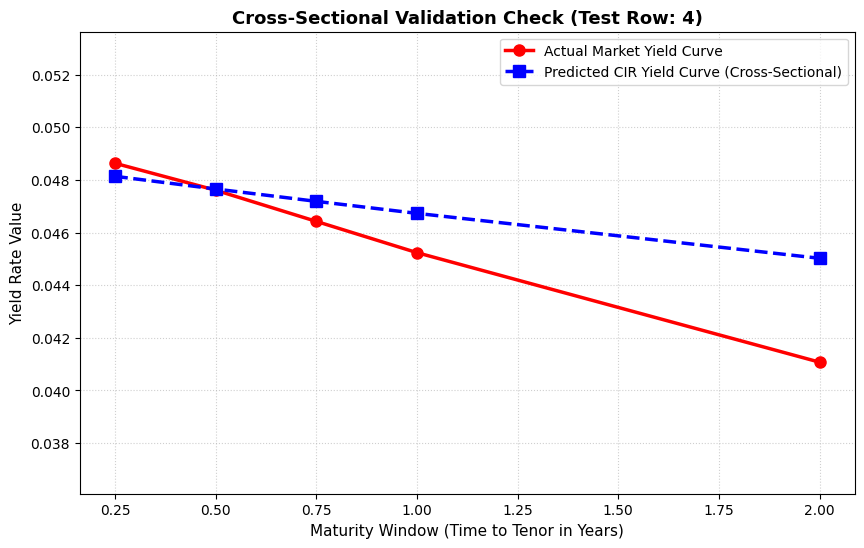

In [26]:

# Extract actual market yield curves for selected test maturities
actual_yields = test_full[[
    'ZC025YR',
    'ZC050YR',
    'ZC075YR',
    'ZC100YR',
    'ZC200YR'
]].values

# Choose a specific day (first day in test set) for comparison
day = 4

# Define corresponding maturity values (in years)
maturities_list = [0.25, 0.5, 0.75, 1.0, 2.0]

# Get actual yield curve for selected day
actual_curve = actual_yields[day]

# Get CIR model predicted yield curve for same day
predicted_curve = predicted_yields[day]

# Display numerical comparison of both curves
print("Actual curve targets for selected day:\n", actual_curve)
print("Optimized Model reconstructed predictions:\n", predicted_curve)


# Create plot for visual comparison
plt.figure(figsize=(10, 6))

# Plot actual market yield curve
plt.plot(
    maturities_list,
    actual_curve,
    color='red',
    marker='o',
    markersize=8,
    linewidth=2.5,
    label='Actual Market Yield Curve'
)

# Plot CIR model predicted yield curve
plt.plot(
    maturities_list,
    predicted_curve,
    color='blue',
    marker='s',
    markersize=8,
    linewidth=2.5,
    linestyle='--',
    label='Predicted CIR Yield Curve (Cross-Sectional)'
)

# Set axis labels
plt.xlabel("Maturity Window (Time to Tenor in Years)", fontsize=11)
plt.ylabel("Yield Rate Value", fontsize=11)

# Set plot title
plt.title(f"Cross-Sectional Validation Check (Test Row: {day})", fontsize=13, fontweight='bold')

# Dynamically adjust y-axis limits for better visualization
y_min = min(actual_curve.min(), predicted_curve.min())
y_max = max(actual_curve.max(), predicted_curve.max())
plt.ylim(y_min - 0.005, y_max + 0.005)

# Add legend and grid for clarity
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **Model Performance Evaluation Metrics**

Model performance is assessed using standard statistical evaluation metrics. The Root Mean Squared Error (RMSE) measures the magnitude of prediction errors while assigning greater weight to large deviations. The Mean Absolute Error (MAE) provides the average absolute difference between observed and predicted yields. The coefficient of determination (R²) evaluates how much of the variation in market yields is explained by the calibrated model.

Although these metrics provide a useful summary of predictive accuracy, they do not capture all aspects of interest rate dynamics. The CIR model remains a single-factor framework and may not fully represent complex yield curve movements observed in financial markets.

In [27]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Convert 2D yield matrices into 1D arrays for global comparison
# (combines all days and maturities into one long vector)
actual_flat = actual_yields.flatten()
predicted_flat = predicted_yields.flatten()

# Calculate Standard Performance Metrics
rmse = np.sqrt(mean_squared_error(actual_flat, predicted_flat))
mae = mean_absolute_error(actual_flat, predicted_flat)
r2 = r2_score(actual_flat, predicted_flat)

# Print final model performance summary
print("  CROSS-SECTIONAL CIR MODEL PERFORMANCE  ")
print(f"RMSE (Root Mean Squared Error) : {rmse:.6f}")
print(f"MAE  (Mean Absolute Error)     : {mae:.6f}")
print(f"R2 Score (Coefficient of Det.) : {r2:.6f}")


# 2. Per-maturity breakdown(Tenor accuracy analysis)

# Explicit maturities array matching columns: index 0=6M, 1=9M, 2=1Y, 3=2Y
maturity_labels = ['6-Month (6M)', '9-Month (9M)', '1-Year (1Y)', '2-Year (2Y)']

print(" Per-maturity breakdown")

# Loop through each maturity column (0 to 3) to isolate specific tenors
for i, label in enumerate(maturity_labels):
    actual_tenor = actual_yields[:, i]
    predicted_tenor = predicted_yields[:, i]

    # Calculate specific metrics for this individual maturity horizon
    tenor_rmse = np.sqrt(mean_squared_error(actual_tenor, predicted_tenor))
    tenor_mae = mean_absolute_error(actual_tenor, predicted_tenor)
    tenor_r2 = r2_score(actual_tenor, predicted_tenor)
    tenor_mse_loss = mean_squared_error(actual_tenor, predicted_tenor)

    print(f"  Tenor: {label}")
    print(f"  RMSE     : {tenor_rmse:.6f}")
    print(f"  MAE      : {tenor_mae:.6f}")
    print(f"  R2 Score : {tenor_r2:.6f}")



  CROSS-SECTIONAL CIR MODEL PERFORMANCE  
RMSE (Root Mean Squared Error) : 0.001966
MAE  (Mean Absolute Error)     : 0.001165
R2 Score (Coefficient of Det.) : 0.923706
 Per-maturity breakdown
  Tenor: 6-Month (6M)
  RMSE     : 0.000213
  MAE      : 0.000147
  R2 Score : 0.999372
  Tenor: 9-Month (9M)
  RMSE     : 0.000588
  MAE      : 0.000431
  R2 Score : 0.994435
  Tenor: 1-Year (1Y)
  RMSE     : 0.001301
  MAE      : 0.000968
  R2 Score : 0.967516
  Tenor: 2-Year (2Y)
  RMSE     : 0.001973
  MAE      : 0.001472
  R2 Score : 0.910154


# **Analysis**
Practical and theoretical limitations of this improved calibrated base CIR model:-


 Improved calibration framework for the standard CIR model using a cross-sectional optimization framework:-
(An enhanced calibration methodology applied to the standard CIR model)


->How it thinks: This model looks at the entire yield curve grid (3M out to 30Y) simultaneously. It forces the math to twist and bend so that the theoretical CIR curve lands as close as possible to all real market rates on those days.

->The Theoretical limitation: It forces a rigid, single-factor equation to fit a multi-factor reality. In the real world, the yield curve moves due to multiple independent forces (short-term rate changes, long-term inflation expectations, risk premiums).

->The Practical Failure: While this method gives you a much higher $R^2$ score (85%+) because it matches today's prices beautifully, it often "cheats" on the time-series dynamics. The parameters it finds might look great across the curve for today, but they frequently describe a completely unrealistic path for how interest rates actually evolve day-by-day over time.



# **Real-World Trading & Risk Management Implications**
The choice of calibration methodology can have a significant impact on how the CIR model is used in practical financial applications. Although the cross-sectional calibration approach improves the model's ability to fit the observed yield curve, it also introduces certain advantages and limitations that should be considered.

## Trading and Arbitrage Applications

In trading environments, accurate yield curve estimation is important for identifying potential mispricing opportunities. A poorly calibrated model may incorrectly suggest that certain bonds are overpriced or underpriced, leading to ineffective trading decisions.

The cross-sectional calibration approach provides a closer fit to the observed market yield curve by incorporating information from multiple maturities simultaneously. As a result, the model is generally more effective for relative-value analysis and yield curve comparison across different maturities.

However, traders should remember that the model remains a simplified representation of the market and may not capture all sources of interest rate risk during rapidly changing market conditions.

## Risk Management and Safeguarding

Risk managers use interest rate models to estimate future movements in yields and to construct Safeguarding strategies. Since the standard CIR model is driven by a single factor, it may not fully capture complex changes occurring across different parts of the yield curve.

The cross-sectional calibration improves the overall fit of the model, but the estimated parameters can still vary over time as market conditions change. This means that safeguard ratios and risk estimates may need to be updated regularly to remain effective.

Consequently, the model should be viewed as a useful analytical tool rather than a complete description of market dynamics.


Answers to some of the important questions:-

Q1 Where does the base CIR model systematically over- or underestimate yields, and why?

The CIR model generally provides a better fit for short- and medium-term maturities. However, it may overestimate or underestimate longer-term yields because the single-factor structure cannot fully capture the complex movements observed across the entire yield curve as you can see from the evaluation metrics cell.

Q2 Does the chosen improved calibrataion meaningfully improve out-of-sample performance, or does it overfit the training period?

The cross-sectional calibration approach improved the model's ability to reconstruct unseen yield curves without relying solely on the training data. The out-of-sample evaluation metrics suggest that the improvement reflects better generalization rather than simple overfitting.

Q3 What mathematical structure justifies the chosen extension over the alternatives?

The cross-sectional calibration framework utilizes information from multiple maturities simultaneouslY.It dynamically tunes the parameters so the model can actually replicate complex, real-world yield curves (like upward-sloping or inverted curves) during out-of-sample testing, allowing the estimated parameters to reflect the overall shape of the yield curve.  This provides a more comprehensive calibration than approaches based on a single maturity.

